In [47]:
import os
import random
import json
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler
import csv

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.grid'] = True
plt.style.use('seaborn-v0_8')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

os.makedirs("artifacts/figures", exist_ok=True)

Using device: cuda


Total observations: 4320
Date range: 2025-01-01 00:00:00 to 2025-06-29 23:00:00
Missing values:
date      0
target    0
dtype: int64


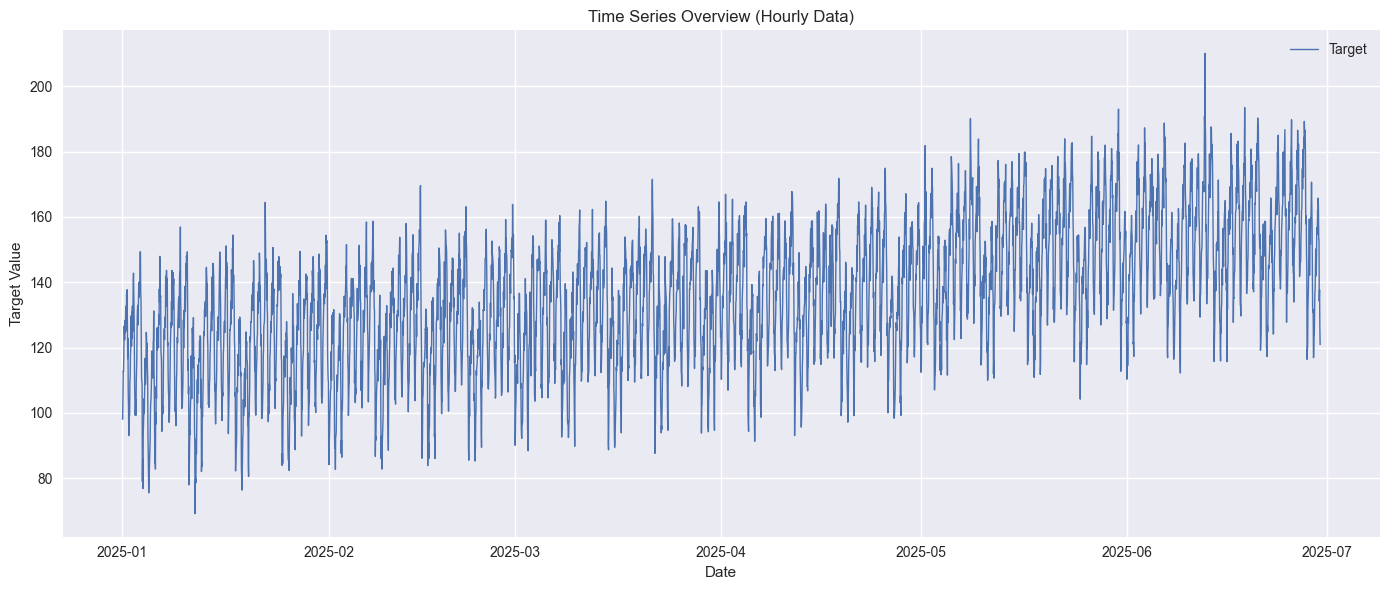

In [37]:
data_path = "S12-hw-dataset.csv"
df = pd.read_csv(data_path)

df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

print(f"Total observations: {len(df)}")
print(f"Date range: {df['date'].min()} to {df['date'].max()}")
print(f"Missing values:\n{df.isnull().sum()}")

plt.figure(figsize=(14, 6))
plt.plot(df['date'], df['target'], label='Target', linewidth=1)
plt.title('Time Series Overview (Hourly Data)')
plt.xlabel('Date')
plt.ylabel('Target Value')
plt.legend()
plt.tight_layout()
plt.show()

Train: 2592 (2025-01-01 00:00:00 - 2025-04-18 23:00:00)
Val:   864 (2025-04-19 00:00:00 - 2025-05-24 23:00:00)
Test:  864 (2025-05-25 00:00:00 - 2025-06-29 23:00:00)


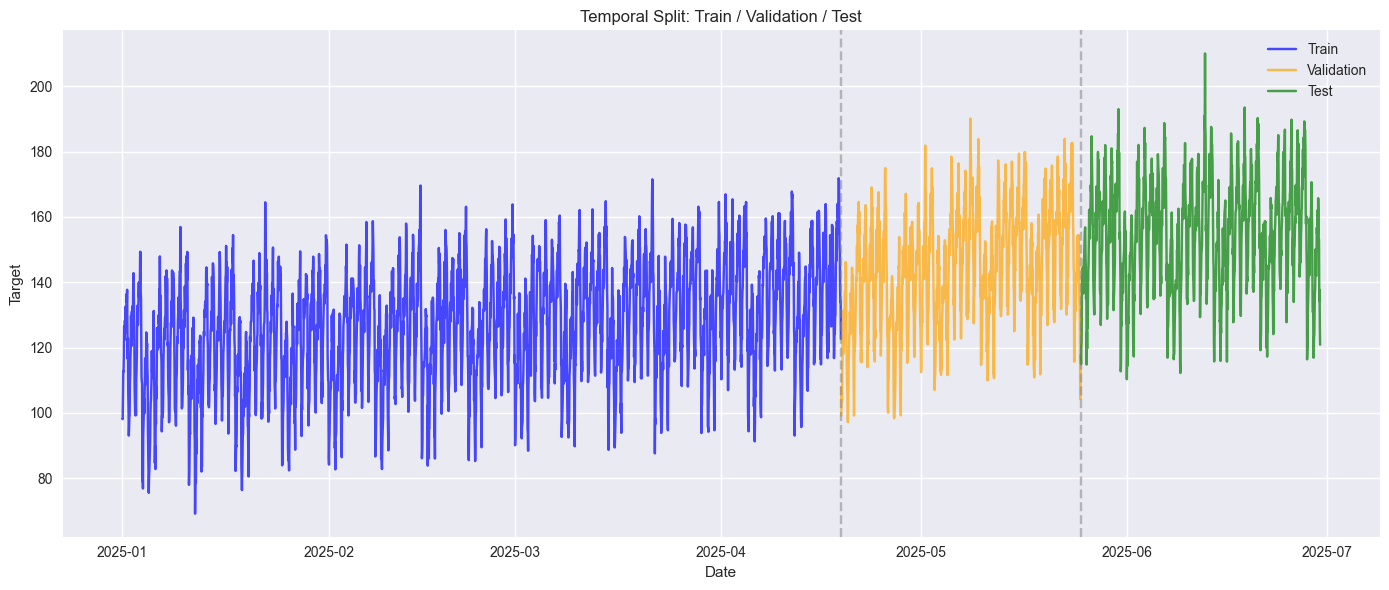

Почему не random split? Случайное перемешивание нарушит хронологию, и модель увидит 'будущее' при обучении, что приведет к утечке данных (data leakage).


In [38]:
n = len(df)
train_size = int(n * 0.6)
val_size = int(n * 0.2)

train_df = df.iloc[:train_size].copy()
val_df = df.iloc[train_size:train_size+val_size].copy()
test_df = df.iloc[train_size+val_size:].copy()

print(f"Train: {len(train_df)} ({train_df['date'].min()} - {train_df['date'].max()})")
print(f"Val:   {len(val_df)} ({val_df['date'].min()} - {val_df['date'].max()})")
print(f"Test:  {len(test_df)} ({test_df['date'].min()} - {test_df['date'].max()})")

# Визуализация сплита
plt.figure(figsize=(14, 6))
plt.plot(train_df['date'], train_df['target'], label='Train', color='blue', alpha=0.7)
plt.plot(val_df['date'], val_df['target'], label='Validation', color='orange', alpha=0.7)
plt.plot(test_df['date'], test_df['target'], label='Test', color='green', alpha=0.7)
plt.axvline(x=train_df['date'].max(), color='gray', linestyle='--', alpha=0.5)
plt.axvline(x=val_df['date'].max(), color='gray', linestyle='--', alpha=0.5)
plt.title('Temporal Split: Train / Validation / Test')
plt.xlabel('Date')
plt.ylabel('Target')
plt.legend()
plt.tight_layout()
plt.savefig("artifacts/figures/series_split.png")
plt.show()

print("Почему не random split? Случайное перемешивание нарушит хронологию, и модель увидит 'будущее' при обучении, что приведет к утечке данных (data leakage).")

In [39]:
def create_features(df):
    df = df.copy()
    df['lag_1'] = df['target'].shift(1)
    df['lag_7'] = df['target'].shift(7)
    df['lag_14'] = df['target'].shift(14)
    df['lag_24'] = df['target'].shift(24)      
    df['lag_168'] = df['target'].shift(168)    
    
    df['rolling_mean_7'] = df['target'].shift(1).rolling(window=7).mean()
    df['rolling_std_7'] = df['target'].shift(1).rolling(window=7).std()
    window = 24
    df['rolling_mean_24'] = df['target'].shift(1).rolling(window=window).mean()
    df['rolling_std_24'] = df['target'].shift(1).rolling(window=window).std()
    
    df['hour'] = df['date'].dt.hour
    df['day_of_week'] = df['date'].dt.dayofweek
    df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)
    
    return df

full_df = create_features(df)


full_df_clean = full_df.dropna().reset_index(drop=True)

n_clean = len(full_df_clean)
train_end = int(n_clean * 0.6)
val_end = int(n_clean * 0.8)

full_train = full_df_clean.iloc[:train_end]
full_val = full_df_clean.iloc[train_end:val_end]
full_test = full_df_clean.iloc[val_end:]

feature_cols = ['lag_1', 'lag_7', 'lag_14', 'lag_24', 'lag_168', 'rolling_mean_7', 'rolling_std_7', 'rolling_mean_24', 'rolling_std_24', 
                'hour', 'day_of_week', 'is_weekend']
target_col = 'target'

X_train = full_train[feature_cols].values
y_train = full_train[target_col].values

X_val = full_val[feature_cols].values
y_val = full_val[target_col].values

X_test = full_test[feature_cols].values
y_test = full_test[target_col].values

print(f"Features shape: Train={X_train.shape}, Val={X_val.shape}, Test={X_test.shape}")

Features shape: Train=(2491, 12), Val=(830, 12), Test=(831, 12)


In [40]:
scaler_features = StandardScaler()
X_train_scaled = scaler_features.fit_transform(X_train)
X_val_scaled = scaler_features.transform(X_val)
X_test_scaled = scaler_features.transform(X_test)

scaler_target = StandardScaler()
y_train_scaled = scaler_target.fit_transform(y_train.reshape(-1, 1)).flatten()
y_val_scaled = scaler_target.transform(y_val.reshape(-1, 1)).flatten()
y_test_scaled = scaler_target.transform(y_test.reshape(-1, 1)).flatten()

def calculate_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mask = y_true != 0
    mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
    return mae, rmse, mape

In [41]:
pred_b1_val = full_val['lag_1'].values
mae_b1, rmse_b1, mape_b1 = calculate_metrics(y_val, pred_b1_val)
print(f"B1 (Naive Last) - Val MAE: {mae_b1:.4f}, RMSE: {rmse_b1:.4f}, MAPE: {mape_b1:.2f}%")

pred_b2_val = full_val['rolling_mean_24'].values
mae_b2, rmse_b2, mape_b2 = calculate_metrics(y_val, pred_b2_val)
print(f"B2 (Moving Avg) - Val MAE: {mae_b2:.4f}, RMSE: {rmse_b2:.4f}, MAPE: {mape_b2:.2f}%")

B1 (Naive Last) - Val MAE: 6.4229, RMSE: 8.1169, MAPE: 4.53%
B2 (Moving Avg) - Val MAE: 13.1324, RMSE: 15.9406, MAPE: 9.37%


In [42]:
model_ridge = Ridge(alpha=1.0)
model_ridge.fit(X_train_scaled, y_train)

pred_b3_val = model_ridge.predict(X_val_scaled)
mae_b3, rmse_b3, mape_b3 = calculate_metrics(y_val, pred_b3_val)
print(f"B3 (Ridge) - Val MAE: {mae_b3:.4f}, RMSE: {rmse_b3:.4f}, MAPE: {mape_b3:.2f}%")

B3 (Ridge) - Val MAE: 5.1927, RMSE: 6.6236, MAPE: 3.57%


In [43]:
class TimeSeriesDataset(Dataset):
    def __init__(self, X, y, window_size):
        self.X = X
        self.y = y
        self.window_size = window_size
        
    def __len__(self):
        return len(self.X) - self.window_size
    
    def __getitem__(self, idx):
        x = self.X[idx : idx + self.window_size]
        
        y_val = self.y[idx + self.window_size]
        return torch.FloatTensor(x), torch.FloatTensor([y_val]).squeeze() 
    
WINDOW_SIZE = 24
BATCH_SIZE = 64

train_dataset = TimeSeriesDataset(X_train_scaled, y_train_scaled, WINDOW_SIZE)
val_dataset = TimeSeriesDataset(X_val_scaled, y_val_scaled, WINDOW_SIZE)
test_dataset = TimeSeriesDataset(X_test_scaled, y_test_scaled, WINDOW_SIZE)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=False) 
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train batches: {len(train_loader)}, Window: {WINDOW_SIZE}")

xb, yb = next(iter(train_loader))
print(f"Batch X shape: {xb.shape}, Batch y shape: {yb.shape}")


Train batches: 39, Window: 24
Batch X shape: torch.Size([64, 24, 12]), Batch y shape: torch.Size([64])


Training GRU...
Epoch 5/30, Train Loss: 0.111424, Val Loss: 0.168419
Epoch 10/30, Train Loss: 0.103283, Val Loss: 0.144365
Epoch 15/30, Train Loss: 0.097350, Val Loss: 0.136213
Epoch 20/30, Train Loss: 0.095351, Val Loss: 0.135288
Epoch 25/30, Train Loss: 0.092596, Val Loss: 0.140741
Epoch 30/30, Train Loss: 0.089476, Val Loss: 0.148171
Best model saved to artifacts/best_gru.pt


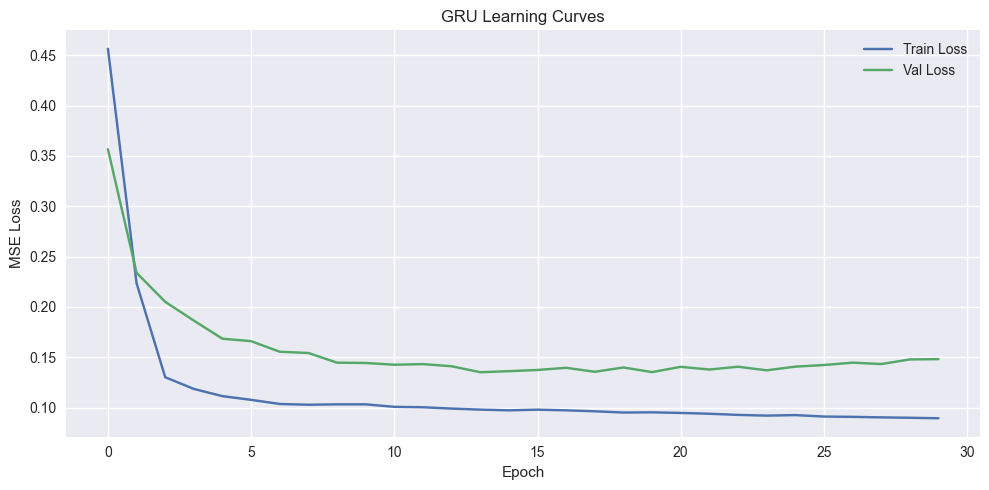

In [44]:
class GRUForecaster(nn.Module):
    def __init__(self, input_size, hidden_size=48, num_layers=2, dropout=0.1):
        super().__init__()
        self.gru = nn.GRU(input_size=input_size, hidden_size=hidden_size, 
                          num_layers=num_layers, batch_first=True, dropout=dropout)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, h_n = self.gru(x)
        last_hidden = h_n[-1] 
        return self.fc(last_hidden).squeeze(-1)

INPUT_SIZE = X_train_scaled.shape[1]
HIDDEN_SIZE = 48
NUM_LAYERS = 2
LEARNING_RATE = 1e-3
EPOCHS = 30

model_gru = GRUForecaster(INPUT_SIZE, HIDDEN_SIZE, NUM_LAYERS).to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model_gru.parameters(), lr=LEARNING_RATE)

best_val_loss = float('inf')
best_model_state = None
history = {'train_loss': [], 'val_loss': []}

print("Training GRU...")
for epoch in range(EPOCHS):
    
    model_gru.train()
    train_losses = []
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        
        optimizer.zero_grad()
        output = model_gru(X_batch)
        loss = criterion(output, y_batch)
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())
    
    model_gru.eval()
    val_losses = []
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            output = model_gru(X_batch)
            loss = criterion(output, y_batch)
            val_losses.append(loss.item())
            
    avg_train = np.mean(train_losses)
    avg_val = np.mean(val_losses)
    
    history['train_loss'].append(avg_train)
    history['val_loss'].append(avg_val)
    
    if avg_val < best_val_loss:
        best_val_loss = avg_val
        best_model_state = model_gru.state_dict().copy()
        
    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1}/{EPOCHS}, Train Loss: {avg_train:.6f}, Val Loss: {avg_val:.6f}")

model_gru.load_state_dict(best_model_state)
torch.save(best_model_state, "artifacts/best_gru.pt")
print("Best model saved to artifacts/best_gru.pt")

plt.figure(figsize=(10, 5))
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.title('GRU Learning Curves')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.tight_layout()
plt.savefig("artifacts/figures/gru_learning_curves.png")
plt.show()

R1 (GRU) - Val MAE: 5.3616, RMSE: 6.9056, MAPE: 3.65%

Лучшая модель на Validation: Ridge (B3)


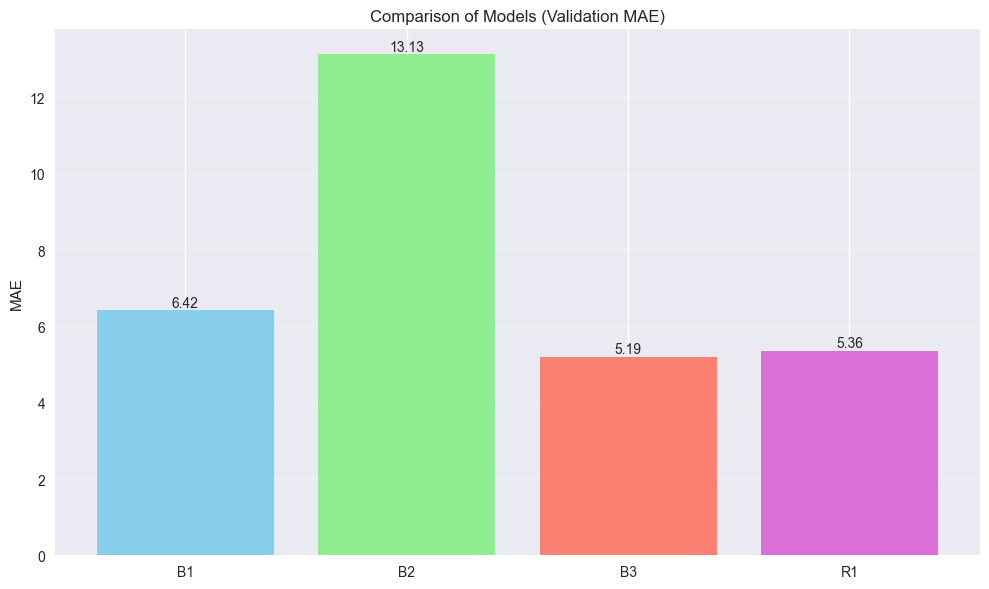

In [45]:
model_gru.eval()
all_preds_val = []
all_targets_val = []

with torch.no_grad():
    for X_batch, y_batch in val_loader:
        X_batch = X_batch.to(device)
        output = model_gru(X_batch)
        all_preds_val.extend(output.cpu().numpy().flatten())
        all_targets_val.extend(y_batch.numpy().flatten())

pred_r1_val_scaled = np.array(all_preds_val)
target_val_scaled = np.array(all_targets_val)

pred_r1_val = scaler_target.inverse_transform(pred_r1_val_scaled.reshape(-1, 1)).flatten()
target_val_orig = scaler_target.inverse_transform(target_val_scaled.reshape(-1, 1)).flatten()

mae_r1, rmse_r1, mape_r1 = calculate_metrics(target_val_orig, pred_r1_val)
print(f"R1 (GRU) - Val MAE: {mae_r1:.4f}, RMSE: {rmse_r1:.4f}, MAPE: {mape_r1:.2f}%")

results = {
    'B1': {'mae': mae_b1, 'rmse': rmse_b1, 'mape': mape_b1, 'name': 'Naive Last'},
    'B2': {'mae': mae_b2, 'rmse': rmse_b2, 'mape': mape_b2, 'name': 'Moving Avg'},
    'B3': {'mae': mae_b3, 'rmse': rmse_b3, 'mape': mape_b3, 'name': 'Ridge'},
    'R1': {'mae': mae_r1, 'rmse': rmse_r1, 'mape': mape_r1, 'name': 'GRU'}
}

best_exp_id = min(results, key=lambda x: results[x]['mae'])
print(f"\nЛучшая модель на Validation: {results[best_exp_id]['name']} ({best_exp_id})")

plt.figure(figsize=(10, 6))
models = list(results.keys())
maes = [results[m]['mae'] for m in models]
colors = ['skyblue', 'lightgreen', 'salmon', 'orchid']
bars = plt.bar(models, maes, color=colors)
plt.title('Comparison of Models (Validation MAE)')
plt.ylabel('MAE')
plt.grid(axis='y', alpha=0.3)

for bar, val in zip(bars, maes):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, f'{val:.2f}', ha='center')

plt.tight_layout()
plt.savefig("artifacts/figures/baselines_compare.png")
plt.show()

B3 Final Test - MAE: 5.1141, RMSE: 6.4131, MAPE: 3.28%
Results saved to artifacts/runs.csv


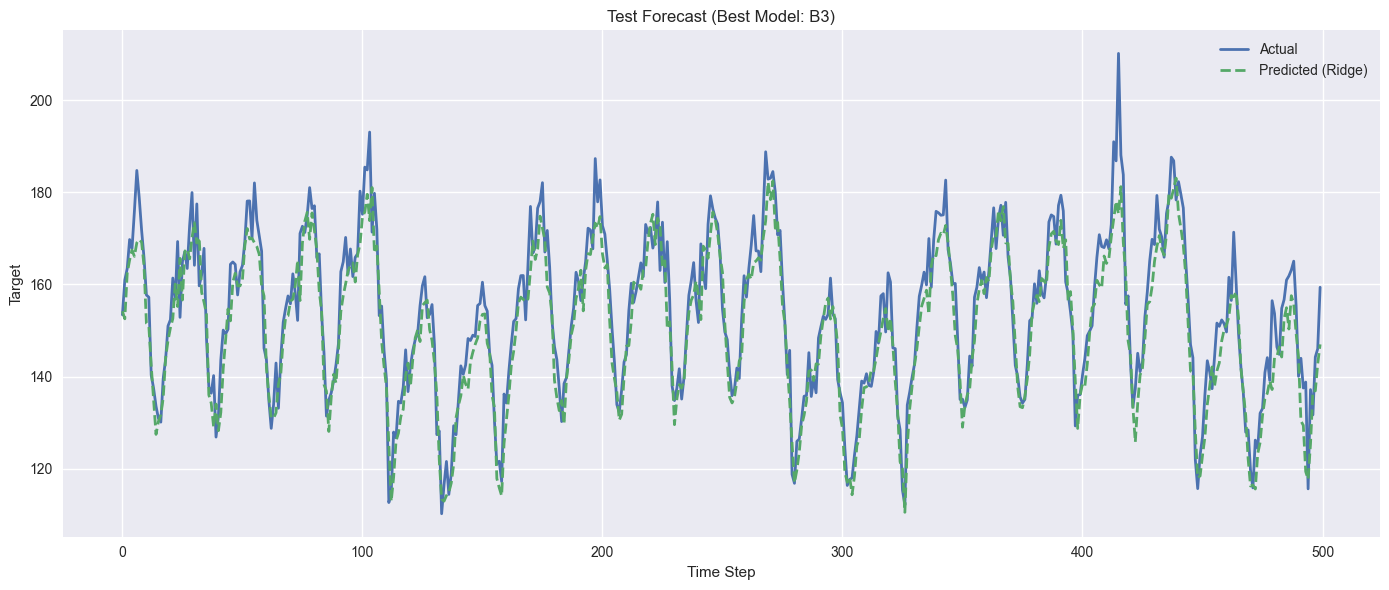

Config saved to artifacts/best_gru_config.json


In [46]:
test_mae, test_rmse, test_mape = 0, 0, 0
plot_pred = None
plot_true = None

if best_exp_id == 'R1':
    all_preds_test = []
    all_targets_test = []
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch = X_batch.to(device)
            output = model_gru(X_batch)
            all_preds_test.extend(output.cpu().numpy().flatten())
            all_targets_test.extend(y_batch.numpy().flatten())
    
    pred_test_scaled = np.array(all_preds_test)
    target_test_scaled = np.array(all_targets_test)
    
    pred_test_orig = scaler_target.inverse_transform(pred_test_scaled.reshape(-1, 1)).flatten()
    target_test_orig = scaler_target.inverse_transform(target_test_scaled.reshape(-1, 1)).flatten()
    
    test_mae, test_rmse, test_mape = calculate_metrics(target_test_orig, pred_test_orig)
    plot_pred = pred_test_orig
    plot_true = target_test_orig
    print(f"R1 Final Test - MAE: {test_mae:.4f}, RMSE: {test_rmse:.4f}, MAPE: {test_mape:.2f}%")

elif best_exp_id == 'B3':
    pred_test = model_ridge.predict(X_test_scaled)
    test_mae, test_rmse, test_mape = calculate_metrics(y_test, pred_test)
    plot_pred = pred_test
    plot_true = y_test
    print(f"B3 Final Test - MAE: {test_mae:.4f}, RMSE: {test_rmse:.4f}, MAPE: {test_mape:.2f}%")
else:
    col_map = {'B1': 'lag_1', 'B2': 'rolling_mean_24'}
    pred_test = full_test[col_map[best_exp_id]].values
    test_mae, test_rmse, test_mape = calculate_metrics(full_test['target'].values, pred_test)
    plot_pred = pred_test
    plot_true = full_test['target'].values
    print(f"{best_exp_id} Final Test - MAE: {test_mae:.4f}, RMSE: {test_rmse:.4f}, MAPE: {test_mape:.2f}%")

# Create temporal split summary
train_date_start = train_df['date'].min().strftime('%Y-%m-%d')
train_date_end = train_df['date'].max().strftime('%Y-%m-%d')
val_date_start = val_df['date'].min().strftime('%Y-%m-%d')
val_date_end = val_df['date'].max().strftime('%Y-%m-%d')
test_date_start = test_df['date'].min().strftime('%Y-%m-%d')
test_date_end = test_df['date'].max().strftime('%Y-%m-%d')
split_summary = f"Train: {train_date_start}-{train_date_end} / Val: {val_date_start}-{val_date_end} / Test: {test_date_start}-{test_date_end}"

runs_data = [
    {
        'experiment_id': 'B1', 'task': 'forecasting', 'dataset': 'S12-hw-dataset', 'seed': SEED,
        'split_summary': split_summary, 'window_size': 'N/A', 'horizon': 1, 'model_summary': 'Naive Last',
        'features_summary': 'lag_1', 'scaler': 'None', 'optimizer': 'N/A', 'lr': 'N/A', 'epochs_trained': 0,
        'best_val_mae': mae_b1, 'best_val_rmse': rmse_b1, 'best_val_mape': mape_b1,
        'test_mae': test_mae if best_exp_id=='B1' else '', 'test_rmse': test_rmse if best_exp_id=='B1' else '', 'test_mape': test_mape if best_exp_id=='B1' else '', 'notes': 'Baseline'
    },
    {
        'experiment_id': 'B2', 'task': 'forecasting', 'dataset': 'S12-hw-dataset', 'seed': SEED,
        'split_summary': split_summary, 'window_size': '24', 'horizon': 1, 'model_summary': 'Moving Average',
        'features_summary': 'rolling_mean_24', 'scaler': 'None', 'optimizer': 'N/A', 'lr': 'N/A', 'epochs_trained': 0,
        'best_val_mae': mae_b2, 'best_val_rmse': rmse_b2, 'best_val_mape': mape_b2,
        'test_mae': test_mae if best_exp_id=='B2' else '', 'test_rmse': test_rmse if best_exp_id=='B2' else '', 'test_mape': test_mape if best_exp_id=='B2' else '', 'notes': 'Baseline'
    },
    {
        'experiment_id': 'B3', 'task': 'forecasting', 'dataset': 'S12-hw-dataset', 'seed': SEED,
        'split_summary': split_summary, 'window_size': 'N/A', 'horizon': 1, 'model_summary': 'Ridge Regression',
        'features_summary': 'lag_1, lag_7, lag_14, lag_24, lag_168, rolling_mean_7, rolling_std_7, rolling_mean_24, rolling_std_24, hour, day_of_week, is_weekend', 'scaler': 'Standard', 'optimizer': 'Closed Form', 'lr': 'N/A', 'epochs_trained': 0,
        'best_val_mae': mae_b3, 'best_val_rmse': rmse_b3, 'best_val_mape': mape_b3,
        'test_mae': test_mae if best_exp_id=='B3' else '', 'test_rmse': test_rmse if best_exp_id=='B3' else '', 'test_mape': test_mape if best_exp_id=='B3' else '', 'notes': 'Linear Model'
    },
    {
        'experiment_id': 'R1', 'task': 'forecasting', 'dataset': 'S12-hw-dataset', 'seed': SEED,
        'split_summary': split_summary, 'window_size': WINDOW_SIZE, 'horizon': 1, 'model_summary': f'GRU({HIDDEN_SIZE}, {NUM_LAYERS})',
        'features_summary': 'lag_1, lag_7, lag_14, lag_24, lag_168, rolling_mean_7, rolling_std_7, rolling_mean_24, rolling_std_24, hour, day_of_week, is_weekend', 'scaler': 'Standard', 'optimizer': 'Adam', 'lr': LEARNING_RATE, 'epochs_trained': EPOCHS,
        'best_val_mae': mae_r1, 'best_val_rmse': rmse_r1, 'best_val_mape': mape_r1,
        'test_mae': test_mae if best_exp_id=='R1' else '', 'test_rmse': test_rmse if best_exp_id=='R1' else '', 'test_mape': test_mape if best_exp_id=='R1' else '', 'notes': 'Deep Learning'
    }
]

with open('artifacts/runs.csv', 'w', newline='') as f:
    writer = csv.DictWriter(f, fieldnames=runs_data[0].keys())
    writer.writeheader()
    writer.writerows(runs_data)
print("Results saved to artifacts/runs.csv")

plt.figure(figsize=(14, 6))
plot_len = min(500, len(plot_true)) 
plt.plot(plot_true[:plot_len], label='Actual', linewidth=2)
plt.plot(plot_pred[:plot_len], label=f'Predicted ({results[best_exp_id]["name"]})', linestyle='--', linewidth=2)
plt.title(f'Test Forecast (Best Model: {best_exp_id})')
plt.xlabel('Time Step')
plt.ylabel('Target')
plt.legend()
plt.tight_layout()
plt.savefig("artifacts/figures/best_forecast_test.png")
plt.show()

config = {
    "window_size": WINDOW_SIZE,
    "hidden_size": HIDDEN_SIZE,
    "num_layers": NUM_LAYERS,
    "batch_size": BATCH_SIZE,
    "learning_rate": LEARNING_RATE,
    "epochs": EPOCHS,
    "seed": SEED,
    "input_features": feature_cols,
    "scaler": "StandardScaler"
}
with open("artifacts/best_gru_config.json", "w") as f:
    json.dump(config, f, indent=4)
print("Config saved to artifacts/best_gru_config.json")